# Hyperspectral plant segmentation in fabricated ecosystems — inference reproduction

Reproduction of the segmentation inference from:

**Zwart P. H., Andeer P., Northen T. R. (2025). "Hyperspectral segmentation of plants in fabricated ecosystems."**
*Frontiers in High Performance Computing* 3:1547340, 17 Feb 2025. DOI: [10.3389/fhpcp.2025.1547340](https://doi.org/10.3389/fhpcp.2025.1547340) (CC BY 4.0).

- **Code (author):** [`phzwart/ecospec`](https://github.com/phzwart/ecospec) @ commit `65ca88ab57168ed9fb5c2d7443437c100451244e` (BSD-3-Clause), with [`dlsia`](https://github.com/phzwart/dlsia) Sparse Mixed-Scale Networks and [`qlty`](https://github.com/phzwart/qlty) patch stitching.
- **Data + trained weights (author):** Zenodo record [14607017](https://zenodo.org/records/14607017) (CC BY 4.0): five `new_network_*.pt` ensembles and the sample EcoFAB growth series `sample_data.tar.bz2` (3.65 GB).

**Scope (partial demonstration):** pretrained **inference only**. We segment the plant in the sample EcoFAB hyperspectral growth series (`YY24EX0010EF009`, front view, 12 time points, 204 bands, 512×512 px) using the five paper-trained ensemble networks, and visualize the plant-class probability and ensemble standard-deviation uncertainty maps, following paper §3.4 (256×256 patches, 248×248 step, probabilities averaged across overlapping patches and the five networks, then renormalized). Training, the SVD ensemble analysis, and the UMAP/NDVI health analysis are **out of scope**.

**Execution status:** validated end-to-end on a fresh Google Colab **CPU** runtime (2026-10-07). No GPU is required; the notebook auto-uses CUDA if a GPU runtime is attached.

**AI-generated glue notice / AI生成コードに関する注意:** The authors did not publish an end-to-end inference script. The ensemble/patch-stitching cells below are **AI-generated glue written strictly on top of the authors' own classes** (`ecospec.core.spectral_segmenter.specseg_from_file`, `ecospec.core.normalize_data.prep_and_normalize`, `qlty.qlty2D.NCYXQuilt`) following paper §3.4. The executed example and listed checks were validated, but untested behavior is not guaranteed.

**日本語要約:** 本ノートブックは、Zwart ら (2025) の hyperspectral セグメンテーション推論を Colab CPU で再現します。Zenodo のサンプル EcoFAB 生育時系列 (12 時点, 204 バンド) を著者 trained 5 ネットワーク・アンサンブルで推論し、植物クラス確率マップとアンサンブル標準偏差 (不確かさ) マップを可視化します。学習・SVD 解析・UMAP/NDVI 解析は対象外です。実行時間の目安: ダウ込み約 3.65 GB を含め全体で 20〜40 分程度です。

## Runtime selection / ランタイム選択

**Recommended runtime: CPU** (menu: Runtime → Change runtime type → CPU). The five networks are tiny (≤0.5 MB each) and inference on one 512×512 time point takes ≈80 s on a standard Colab CPU. A GPU (T4) also works — the code auto-detects CUDA — but is unnecessary.

**Downloads:** ≈3.65 GB (single Zenodo tarball; the paper's only public sample input — it cannot be partially fetched because bzip2 archives are not seekable). **Run all** end-to-end budget: ≈20–40 min.

**推奨ランタイムは CPU です。** モデルは極小 (各 ≤0.5 MB) で、512×512 の 1 時点あたり CPU で約 80 秒です。GPU も自動検出して利用しますが不要です。ダウンロードは約 3.65 GB、全体の所要は 20〜40 分程度を見込んでください。

In [ ]:
import sys, time, subprocess
t_notebook = time.time()
print("Python:", sys.version.split()[0])
import torch
print("torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

Python: 3.13.16


torch: 2.11.0+cpu | CUDA available: False
device: cpu


## 1. Pinned dependency setup / 依存関係の固定インストール

Installs the author stack at paper-matched versions:
- `dlsia==0.3.1` — the last dlsia release (2024-04) predating the Jan 2025 checkpoints; installed `--no-deps` and only its import-graph requirements are added, because dlsia's own metadata pins many unrelated documentation packages. `torch` is preinstalled on Colab.
- `ecospec` — installed `--no-deps` from the author's pinned commit.
- `qlty==0.2.0` — the author's patch/stitch library, version era-matched to the paper (2024-07).

**日本語:** 論文のチェックポイント (2025-01) に時代整合な `dlsia==0.3.1` と、著者リポジトリの固定コミットから `ecospec`、そして `qlty==0.2.0` をインストールします。dlsia は不要な依存が多いため `--no-deps` で入れ、import に必要な最小限だけ追加します。

In [ ]:
%%bash
set -e
pip install --no-deps -q dlsia==0.3.1
pip install -q networkx plotly torchsummary einops zarr spectral scikit-image "qlty==0.2.0"
pip install --no-deps -q "ecospec @ git+https://github.com/phzwart/ecospec@65ca88ab57168ed9fb5c2d7443437c100451244e"
python -c "import torch, dlsia, ecospec, qlty, zarr, spectral, skimage; print('stack import OK')" 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.7/114.7 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.2/215.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.9/376.9 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.5/230.5 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 49.4 MB/s eta 0:00:00
stack import OK


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dlsia 0.3.1 requires connected-components-3d, which is not installed.
dlsia 0.3.1 requires jedi>=0.10, which is not installed.
dlsia 0.3.1 requires kaleido, which is not installed.
dlsia 0.3.1 requires lxml-html-clean, which is not installed.
dlsia 0.3.1 requires m2r, which is not installed.
dlsia 0.3.1 requires nbsphinx, which is not installed.
dlsia 0.3.1 requires nbsphinx-link, which is not installed.
dlsia 0.3.1 requires papermill, which is not installed.
dlsia 0.3.1 requires pytorch-lightning, which is not installed.
dlsia 0.3.1 requires sphinx-rtd-theme, which is not installed.
dlsia 0.3.1 requires torchmetrics>=0.11.0, which is not installed.
dlsia 0.3.1 requires torchmetrics>=0.4.1, which is not installed.
dlsia 0.3.1 requires typing>=3.7.4.3, which is not installed.
dlsia 0.3.1 requires networkx==3.0, but

The `ecospec` wheel does **not** ship its bundled `ecospec/reference/*.npy` alignment references (the sdist `MANIFEST.in` omits them), so the next cell restores the six arrays from the pinned commit and **verifies each file's git blob SHA-1** against the GitHub tree API values recorded for commit `65ca88ab`. These are data files and are fetched here (Colab) only.

**日本語:** `ecospec` の wheel には同梱参照配列 `reference/*.npy` が含まれないため、固定コミットから取得し、各ファイルの git blob SHA-1 を検証して復元します（データは Colab 内でのみ取得）。

In [ ]:
import hashlib, pathlib, urllib.request
import ecospec
ECOSPEC_SHA = "65ca88ab57168ed9fb5c2d7443437c100451244e"
BASE = f"https://raw.githubusercontent.com/phzwart/ecospec/{ECOSPEC_SHA}/ecospec/reference"
BLOB_SHA1 = {  # git blob sha1 at the pinned commit (GitHub tree API)
    "front_mask.npy": "9fcafc2d1493ac67a16d5fddb4c1283c4b51b862",
    "front_mean.npy": "b57352e508474941a8251c3120225d752be788b5",
    "side_mask.npy":  "a046039d5db11bda35da39a7d3a092592fcac263",
    "side_mean.npy":  "784c3d64899b4057cf74fe8847c913780a355d4d",
    "top_mask.npy":   "1b84fbc29af7ae49cfe68c41228478100d3d7552",
    "top_mean.npy":   "3abddb4212f2cc866470547654fe59c39a0f67fc",
}
ref_dir = pathlib.Path(ecospec.__path__[0]) / "reference"
ref_dir.mkdir(exist_ok=True)
for fname, expected in BLOB_SHA1.items():
    dest = ref_dir / fname
    if not dest.exists():
        urllib.request.urlretrieve(f"{BASE}/{fname}", dest)
    data = dest.read_bytes()
    sha = hashlib.sha1(b"blob %d\0" % len(data) + data).hexdigest()
    assert sha == expected, f"blob sha mismatch for {fname}"
    print(f"{fname}: {len(data)} bytes, blob sha verified")

front_mask.npy: 2097280 bytes, blob sha verified


front_mean.npy: 2097280 bytes, blob sha verified


side_mask.npy: 2097280 bytes, blob sha verified


side_mean.npy: 2097280 bytes, blob sha verified


top_mask.npy: 2097280 bytes, blob sha verified


top_mean.npy: 2097280 bytes, blob sha verified


## 2. Trained ensemble weights from Zenodo (md5-verified) / Zenodo から学習済み重みを取得

Downloads the five paper-trained networks from Zenodo record 14607017 (the record's documented public API), verifying each file's size and md5 against the record metadata. **日本語:** Zenodo 記録 14607017 の公開 API から、論文で学習された 5 つのネットワークを取得し、サイズと md5 を記録値と照合します。

In [ ]:
import json, hashlib, pathlib, urllib.request
ZEN = pathlib.Path("/content/zenodo"); ZEN.mkdir(exist_ok=True)
rec = json.load(urllib.request.urlopen(
    "https://zenodo.org/api/records/14607017", timeout=120))
files = {f["key"]: f for f in rec["files"]}
for key in sorted(files):
    if not key.startswith("new_network_"):
        continue
    f = files[key]
    dest = ZEN / key
    if not dest.exists() or dest.stat().st_size != f["size"]:
        urllib.request.urlretrieve(f["links"]["self"], dest)
    md5 = hashlib.md5(dest.read_bytes()).hexdigest()
    assert md5 == f["checksum"].split(":")[1], f"md5 mismatch for {key}"
    print(key, f["size"], "bytes, md5 verified")

new_network_0.pt 304190 bytes, md5 verified


new_network_1.pt 439530 bytes, md5 verified


new_network_2.pt 277726 bytes, md5 verified


new_network_3.pt 479086 bytes, md5 verified


new_network_4.pt 308302 bytes, md5 verified


Inspect each checkpoint's stored topology (no weight values are printed). This is the author's own `specseg_from_file` format: a spectral projector `FCNetwork` (paper: 64→32→4, 25% dropout) plus an SMSNet spatial network with 2 output classes and 256×256 patch shape. The 64 input channels fix the spectral band selection used below (495–684 nm ⇒ 64 bands of the Specim IQ grid).

**日本語:** 各チェックポイントに保存されたトポロジ (FCNetwork 64→32→4、SMSNet 2 クラス、256×256) を確認します。入力 64 チャネルは下のバンド選択 (495–684 nm ⇒ 64 バンド) と一致します。

In [ ]:
import torch
NET_PARAMS = []
for i in range(5):
    params = torch.load(ZEN / f"new_network_{i}.pt", map_location="cpu", weights_only=False)
    ts, tm = params["topo_dict_spectral"], params["topo_dict_sms"]
    assert ts["Cin"] == 64 and ts["Cout"] == 4 and tm["in_channels"] == 4 and tm["out_channels"] == 2
    assert tuple(tm["in_shape"]) == (256, 256)
    NET_PARAMS.append(params)
    print(f"network {i}: spectral {ts['Cin']}->{ts['Cmiddle']}->{ts['Cout']} (dropout {ts['dropout_rate']}),"
          f" SMSNet {tm['in_channels']}->{tm['out_channels']} patch {tuple(tm['in_shape'])}")

network 0: spectral 64->[32]->4 (dropout 0.25), SMSNet 4->2 patch (256, 256)
network 1: spectral 64->[32]->4 (dropout 0.25), SMSNet 4->2 patch (256, 256)
network 2: spectral 64->[32]->4 (dropout 0.25), SMSNet 4->2 patch (256, 256)
network 3: spectral 64->[32]->4 (dropout 0.25), SMSNet 4->2 patch (256, 256)
network 4: spectral 64->[32]->4 (dropout 0.25), SMSNet 4->2 patch (256, 256)


## 3. Sample EcoFAB growth series (Zenodo, md5-verified) / サンプル生育時系列の取得

Downloads `sample_data.tar.bz2` (3,647,209,950 bytes) — the paper's only public sample input — with a **parallel ranged downloader** (16 threads × 32 MiB chunks, resumable) because Zenodo serves Range requests and a single stream measured ≈2 MB/s in validation. The md5 must match the record (`4a61c4926a109018f79e331bdb4fd185`). The full-archive download is a documented cost: the three view series live in one bzip2 tarball that cannot be partially fetched.

**日本語:** 論文の唯一の公開サンプル入力 `sample_data.tar.bz2` (3.65 GB) を並列レンジダウンロード (16 同時接続 × 32 MiB、レジューム可能) で取得し、md5 を照合します。bz2 tarball は部分取得できないため、アーカイブ全体の取得が必須であることを明示します。

In [ ]:
import concurrent.futures, os, time, hashlib, urllib.request
ARCHIVE = ZEN / "sample_data.tar.bz2"
SIZE = files["sample_data.tar.bz2"]["size"]
MD5_EXPECTED = files["sample_data.tar.bz2"]["checksum"].split(":")[1]

def file_md5(p):
    h = hashlib.md5()
    with open(p, "rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 22), b""):
            h.update(chunk)
    return h.hexdigest()

if ARCHIVE.exists() and ARCHIVE.stat().st_size == SIZE and file_md5(ARCHIVE) == MD5_EXPECTED:
    print("archive already present and md5-verified; skipping download")
else:
    PARTS = ZEN / "parts"; PARTS.mkdir(exist_ok=True)
    CHUNK = 32 << 20
    nchunks = (SIZE + CHUNK - 1) // CHUNK
    print(f"{SIZE/1e9:.2f} GB in {nchunks} chunks of 32 MiB")
    def fetch(i):
        a, b = i * CHUNK, min((i + 1) * CHUNK, SIZE) - 1
        p = PARTS / f"part_{i:05d}"
        if p.exists() and p.stat().st_size == b - a + 1:
            return 0
        for attempt in range(5):
            try:
                req = urllib.request.Request(files["sample_data.tar.bz2"]["links"]["self"],
                                             headers={"Range": f"bytes={a}-{b}"})
                with urllib.request.urlopen(req, timeout=180) as r:
                    data = r.read()
                if len(data) == b - a + 1:
                    p.write_bytes(data)
                    return len(data)
            except Exception:
                time.sleep(2 * attempt + 1)
        raise RuntimeError(f"chunk {i} failed after retries")
    t0 = time.time(); done = 0
    with concurrent.futures.ThreadPoolExecutor(16) as ex:
        for n in concurrent.futures.as_completed([ex.submit(fetch, i) for i in range(nchunks)]):
            done += n.result()
            print(f"\r{done/1e9:.2f} GB at {done/1e6/max(time.time()-t0,1):.0f} MB/s", end="", flush=True)
    print()
    if not ARCHIVE.exists() or ARCHIVE.stat().st_size != SIZE:
        with open(ARCHIVE, "wb") as out:
            for i in range(nchunks):
                out.write((PARTS / f"part_{i:05d}").read_bytes())
    assert ARCHIVE.stat().st_size == SIZE and file_md5(ARCHIVE) == MD5_EXPECTED
    print("archive assembled and md5-verified")

3.65 GB in 109 chunks of 32 MiB


0.03 GB at 2 MB/s

0.07 GB at 4 MB/s

0.10 GB at 5 MB/s

0.13 GB at 5 MB/s

...

3.56 GB at 18 MB/s

3.58 GB at 18 MB/s

3.61 GB at 18 MB/s

3.65 GB at 18 MB/s

archive assembled and md5-verified


Extract **only the front-view zarr store** (`YY24EX0010EF009_series_front.zarr`) in a single streaming pass — the side/top stores stay inside the archive, so we process only the chosen sample. Then locate the store and print its `MultimodalDataset` schema (author class `ecospec.core.spectral_data_object.MultimodalDataset`).

**日本語:** front 視点の zarr ストアのみを単一パスで展開します (side/top はアーカイブ内に残置)。ストアを見つけ、`MultimodalDataset` のスキーマ (形状・dtype・チャンク) を表示します。

In [ ]:
import tarfile
STORE_HINT = "_series_front.zarr"
if not any(root.endswith(STORE_HINT) for root, _, _ in os.walk("/content") if "zarr_files" in root):
    t0 = time.time()
    with tarfile.open(ARCHIVE, "r:bz2") as tf:
        for m in tf:
            if STORE_HINT in m.name:
                tf.extract(m, "/content")
    print(f"extracted front store in {time.time()-t0:.0f}s")
ZARRS = sorted(root for root, _, _ in os.walk("/content")
               if root.endswith(STORE_HINT))
print("zarr stores:", ZARRS)
assert len(ZARRS) == 1

/tmp/ipykernel_2093/1752755121.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extract(m, "/content")


extracted front store in 433s
zarr stores: ['/content/global/cfs/cdirs/als/zwart/ecoBOT/YY24EX0010/zarr_files/YY24EX0010EF009_series_front.zarr']


The store is opened with zarr and its `MultimodalDataset` arrays are printed: `hs_data` (12 time points, 204 bands, 512×512, float64), `rgb_data` (12, 512, 512, 4), `bands` (Specim IQ centers, 397–1000 nm) and `time_points` (2024-05-31 … 2024-06-21). The 495–684 nm selection is confirmed to yield exactly the 64 channels the checkpoints expect. **日本語:** ストアの配列構成 (12 時点 × 204 バンド × 512×512) を確認し、495–684 nm が 64 チャネル (= チェックポイント入力) に対応することを確かめます。

In [ ]:
import zarr, numpy as np
zg = zarr.open_group(ZARRS[0], mode="r")
print("attrs:", dict(zg.attrs))
for k in zg.array_keys():
    a = zg[k]
    print(f"  {k}: shape {a.shape}, dtype {a.dtype}, chunks {a.chunks}")
BANDS = np.asarray(zg["bands"][:])
TIME_POINTS = np.asarray(zg["time_points"][:])
print("bands (nm):", BANDS[:3], "...", BANDS[-3:], "| n =", len(BANDS))
print("n bands in 495-684 nm:", int(((BANDS > 495) & (BANDS < 684)).sum()), "== checkpoint Cin 64")
print("time_points:", TIME_POINTS.astype(int))

attrs: {'additional_metadata': 'front', 'sample_identifier': 'YY24EX0010EF009'}
  rgb_data: shape (12, 512, 512, 4), dtype int64, chunks (10, 512, 512, 4)
  hs_data: shape (12, 204, 512, 512), dtype float64, chunks (10, 10, 512, 512)
  bands: shape (204,), dtype float64, chunks (1000,)
  time_points: shape (12,), dtype float64, chunks (1000,)
bands (nm): [397.32 400.2  403.09] ... [ 997.4  1000.49 1003.58] | n = 204
n bands in 495-684 nm: 64 == checkpoint Cin 64
time_points: [20240531 20240602 20240604 20240606 20240608 20240610 20240612 20240614
 20240616 20240618 20240620 20240621]


## 4. Input preview — RGB with the authors' reference plant mask / 入力プレビュー

The sample is EcoFAB `YY24EX0010EF009` (experiment `YY24EX0010`), front view, captured with a Specim IQ camera (204 bands, 397–1000 nm) and already aligned by the authors' pipeline (`ecospec` `construct_series` → Otsu + FFT cross-correlation against the bundled references). We display the RGB render of the **first time point (2024-05-31)** with the authors' front-view reference plant mask (`ecospec.core.get_reference.mask('front')`, blob-SHA-verified above) overlaid as a contour. This mask is the authors' reference annotation of where plants are expected — it is **not** a model prediction.

**日本語:** サンプルは EcoFAB `YY24EX0010EF009` (front 視点, Specim IQ, 204 バンド, 既整列) です。最初の時点 (2024-05-31) の RGB に、著者提供の front 参照マスク (`get_reference.mask('front')`) を等高線で重ねて表示します。これは参照アノテーションであり、モデル予測ではありません。

rgb: (512, 512, 4) int64 | mask: (512, 512) int64 min/max/mean = 0.000 1.000 0.758


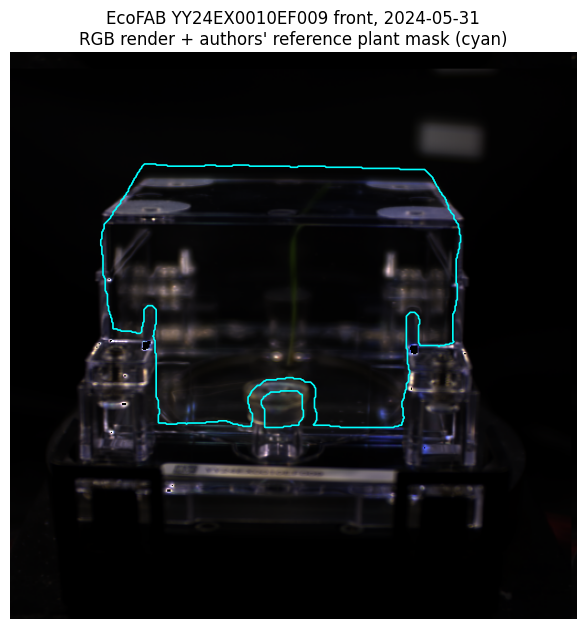

In [ ]:
import matplotlib.pyplot as plt
from ecospec.core import get_reference

rgb = np.asarray(zg["rgb_data"][0])          # (512, 512, 4)
front_mask = np.asarray(get_reference.mask("front"))
print("rgb:", rgb.shape, rgb.dtype, "| mask:", front_mask.shape, front_mask.dtype,
      "min/max/mean = %.3f %.3f %.3f" % (front_mask.min(), front_mask.max(), front_mask.mean()))

fig, ax = plt.subplots(figsize=(6.4, 6.4))
ax.imshow(rgb[..., :3])
ax.contour(front_mask, levels=[0.5], colors="cyan", linewidths=1.2)
ax.set_title("EcoFAB YY24EX0010EF009 front, 2024-05-31\nRGB render + authors' reference plant mask (cyan)")
ax.axis("off")
plt.tight_layout(); plt.show()

A quick spectral look at the same slice: mean reflectance spectrum of the frame with the 495–684 nm projector window shaded (the 64 channels the networks consume).

**日本語:** 同一スライスの平均スペクトルを表示し、ネットワーク入力となる 495–684 nm (64 チャネル) を陰影で示します。

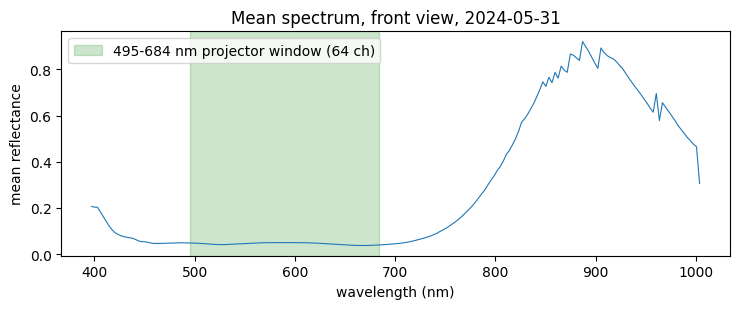

In [ ]:
spec0 = np.asarray(zg["hs_data"][0])          # (204, 512, 512) float64, one zarr chunk slice
mean_spectrum = np.nanmean(spec0, axis=(1, 2))
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.plot(BANDS, mean_spectrum, lw=0.8)
ax.axvspan(495, 684, alpha=0.2, color="green", label="495-684 nm projector window (64 ch)")
ax.set_xlabel("wavelength (nm)"); ax.set_ylabel("mean reflectance")
ax.legend(); ax.set_title("Mean spectrum, front view, 2024-05-31")
plt.tight_layout(); plt.show()

## 5. Preprocessing — author spectral normalization / 前処理

`ecospec.core.normalize_data.prep_and_normalize` (author code) selects the 495–684 nm bands (→ exactly the 64 checkpoint input channels), replaces NaNs, and standardizes each pixel's spectrum (per-pixel mean subtraction and std scaling with `eps=1e-3`), matching the paper's spectral-projector input.

**日本語:** 著者コード `prep_and_normalize` により、495–684 nm (64 バンド = チェックポイントの入力チャネル数) を選択し、画素ごとのスペクトル標準化 (平均減算・std 正規化, eps=1e-3) を行います。

In [ ]:
from ecospec.core import prep_and_normalize

TIME_INDEX = 0  # deterministic minimal example: first time point (2024-05-31)
hs_slice = np.asarray(zg["hs_data"][TIME_INDEX : TIME_INDEX + 1], dtype=np.float32)  # lazy zarr slice
data, new_bands = prep_and_normalize(np.asarray(BANDS), hs_slice)
print("normalized tensor:", tuple(data.shape), data.dtype, "| kept bands:", len(new_bands),
      f"({new_bands[0]:.0f}-{new_bands[-1]:.0f} nm)")

normalized tensor: (1, 64, 512, 512) torch.float32 | kept bands: 64 (496-682 nm)


## 6. Ensemble inference (paper §3.4) / アンサンブル推論

**AI-generated glue** following paper §3.4 and the authors' classes: `qlty.qlty2D.NCYXQuilt` cuts the 512×512 frame into 256×256 patches at 248×248 step (3×3 = 9 patches, 8-px overlap); each of the five networks (`specseg_from_file`) maps patches to 2-class logits; logits are softmaxed to probabilities, averaged across the five networks, stitched back to 512×512 by qlty's weighted averaging, renormalized to sum-to-1, and the per-network standard deviation of the plant class is stitched as the uncertainty map.

**日本語:** 論文 §3.4 に従う AI 生成の接着コードです。qlty が 512×512 を 256×256/ステップ 248 (9 パッチ) に切り出し、5 ネットワーク (`specseg_from_file`) のロジットを softmax → ネットワーク間平均 → qlty で加重平均ステッチ → 再正規化し、植物クラスのネットワーク間標準偏差を不確かさマップとします。

In [ ]:
from ecospec.core import specseg_from_file
from qlty.qlty2D import NCYXQuilt

quilt = NCYXQuilt(Y=data.shape[-2], X=data.shape[-1], window=(256, 256), step=(248, 248), border=0)
patches = quilt.unstitch(data)
print("patches:", tuple(patches.shape))

def ensemble_segment(patches):
    probs = []
    for params in NET_PARAMS:
        net = specseg_from_file(params).to(DEVICE).eval()
        with torch.no_grad():
            logits = net(patches.to(DEVICE))
            probs.append(torch.softmax(logits, dim=1).cpu())
    return torch.stack(probs)  # (5, M, 2, 256, 256)

t0 = time.time()
patch_probs = ensemble_segment(patches)
print("ensemble forward: %.0fs" % (time.time() - t0))

patches: (9, 64, 256, 256)


ensemble forward: 74s


Stitch the ensemble back together exactly as paper §3.4 describes: average the five networks' probabilities, apply qlty's overlap-weighted stitching, renormalize the two class probabilities to sum to one, and stitch the per-network standard deviation into an uncertainty map. **日本語:** 5 ネットワークの確率を平均し、qlty のオーバーラップ重み付きステッチ、クラス確率の再正規化 (合計 1) を行い、ネットワーク間標準偏差を不確かさマップとしてステッチします。

In [ ]:
mean_prob = patch_probs.mean(0)                       # average across networks
stitched, _ = quilt.stitch(mean_prob)                 # weighted average across overlapping patches
stitched = stitched / stitched.sum(1, keepdim=True)   # renormalize (paper §3.4)
plant_prob = stitched[0, 1].numpy()                   # plant class probability, (512, 512)
std_map, _ = quilt.stitch(patch_probs.std(0))         # ensemble std, stitched
plant_std = std_map[0, 1].numpy()
print("plant prob: min %.2e max %.3f | mean %.3f" % (plant_prob.min(), plant_prob.max(), plant_prob.mean()))
print("std map:    max %.3f | mean %.4f" % (plant_std.max(), plant_std.mean()))

plant prob: min 1.26e-09 max 1.000 | mean 0.018
std map:    max 0.543 | mean 0.0247


## 7. Results — probability and uncertainty maps / 結果の可視化

The plant-class probability (left) highlights the Brachypodium plant; the ensemble standard deviation (right) is expected to concentrate at leaf edges and in the EcoFAB housing reflections of the plant (paper Fig. 4). **日本語:** 左は植物クラス確率、右はアンサンブル標準偏差です。論文 Fig. 4 同様、不確かさは葉の縁やエコファブ筐体の反射に集中するはずです。

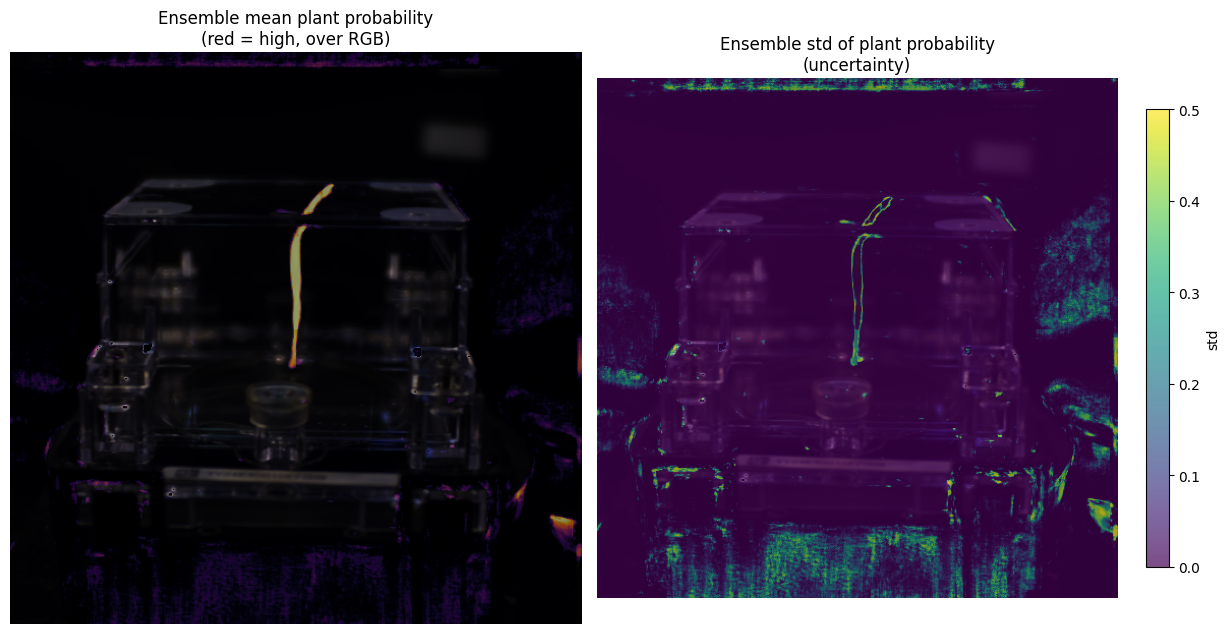

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 6.6))
im0 = axes[0].imshow(rgb[..., :3])
im1 = axes[0].imshow(plant_prob, cmap="inferno", vmin=0, vmax=1, alpha=0.55)
axes[0].set_title("Ensemble mean plant probability\n(red = high, over RGB)")
axes[1].imshow(rgb[..., :3])
im2 = axes[1].imshow(plant_std, cmap="viridis", vmin=0, vmax=0.5, alpha=0.7)
axes[1].set_title("Ensemble std of plant probability\n(uncertainty)")
for ax in axes: ax.axis("off")
fig.colorbar(im2, ax=axes[1], fraction=0.04, label="std")
plt.tight_layout(); plt.show()

A focused view of the uncertainty structure alone, plus the probability as an isolated map.

**日本語:** 確率マップと不確かさマップを単独でも表示します (入力 RGB を重ねない素の値)。

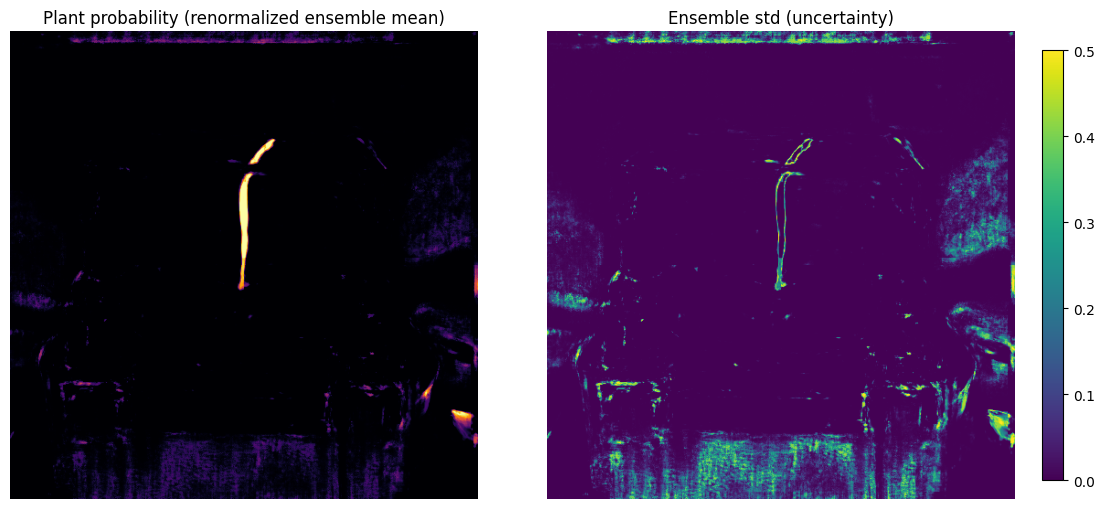

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.2))
axes[0].imshow(plant_prob, cmap="inferno", vmin=0, vmax=1)
axes[0].set_title("Plant probability (renormalized ensemble mean)")
im = axes[1].imshow(plant_std, cmap="viridis", vmin=0, vmax=0.5)
axes[1].set_title("Ensemble std (uncertainty)")
fig.colorbar(im, ax=axes[1], fraction=0.04)
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

## 8. Plausibility check against the authors' reference mask / 参照マスクとの整合チェック

The authors' front-view reference mask marks where plants are expected in aligned frames. This is an **independent plausibility check, not a scored validation** (the mask is a coarse expectation, not pixel-accurate ground truth). We compare mean plant probability inside vs. outside the mask and the thresholded overlap. **日本語:** 著者の参照マスク (植物が期待される領域) と推論結果の整合を確認します。これは粗い期待領域との妥当性チェックであり、正解データとの精度評価ではありません。

In [ ]:
inside = plant_prob[front_mask > 0.5]
outside = plant_prob[front_mask <= 0.5]
pred_plant = plant_prob > 0.5
table = {
    "mean plant prob inside mask": float(inside.mean()),
    "mean plant prob outside mask": float(outside.mean()),
    "fraction pred plant inside mask": float(pred_plant[front_mask > 0.5].mean()),
    "fraction pred plant (whole frame)": float(pred_plant.mean()),
    "fraction mask area": float((front_mask > 0.5).mean()),
}
import pandas as pd
check_df = pd.DataFrame({"value": table})
check_df

,value
mean plant prob inside mask,0.018401
mean plant prob outside mask,0.017066
fraction pred plant inside mask,0.001564
fraction pred plant (whole frame),0.005173
fraction mask area,0.758312


## 9. Growth-series extension (3 time points) / 生育時系列への拡張

To show the temporal dimension of the sample, we segment two more time points (indices 5 and 11 = 2024-06-10 and 2024-06-21) with the identical procedure and plot the plant-probability (>0.5) area fraction across the three dates. This graph is an **additional visualization created for this notebook**, not an author figure. Each extra time point costs ≈80 s on CPU. Results are also exported to CSV. **日本語:** 同一手順で 2 つの追加時点 (2024-06-10, 2024-06-21) を推論し、植物確率 >0.5 の面積割合の推移をグラフ化します (本ノートブック独自の追加可視化で、論文の図ではありません)。

In [ ]:
EXTRA_INDICES = [5, 11]
trend_rows = [{"time_index": TIME_INDEX,
               "date": int(TIME_POINTS[TIME_INDEX]),
               "plant_fraction": float(pred_plant.mean())}]
for idx in EXTRA_INDICES:
    sl = np.asarray(zg["hs_data"][idx : idx + 1], dtype=np.float32)
    d_i, _ = prep_and_normalize(np.asarray(BANDS), sl)
    p_i = ensemble_segment(quilt.unstitch(d_i)).mean(0)
    s_i, _ = quilt.stitch(p_i)
    s_i = s_i / s_i.sum(1, keepdim=True)
    trend_rows.append({"time_index": idx, "date": int(TIME_POINTS[idx]),
                       "plant_fraction": float((s_i[0, 1].numpy() > 0.5).mean())})
    print("time point", idx, "done, total %.0fs" % (time.time() - t_notebook))
trend_df = pd.DataFrame(trend_rows)
trend_df.to_csv("/content/ecospec_plant_fraction.csv", index=False)
trend_df

time point 5 done, total 883s


time point 11 done, total 962s


,time_index,date,plant_fraction
0,0,20240531,0.005173
1,5,20240610,0.013130
2,11,20240621,0.016251


Growth-trend graph of the three segmented dates (area fraction where ensemble plant probability > 0.5). Axis units are the acquisition dates (YYYYMMDD) and a fraction of the 512×512 frame. **日本語:** 3 時点の植物確率 (>0.5) 面積割合のグラフです。横軸は取得日 (YYYYMMDD)、縦軸は 512×512 フレームに占める割合です。

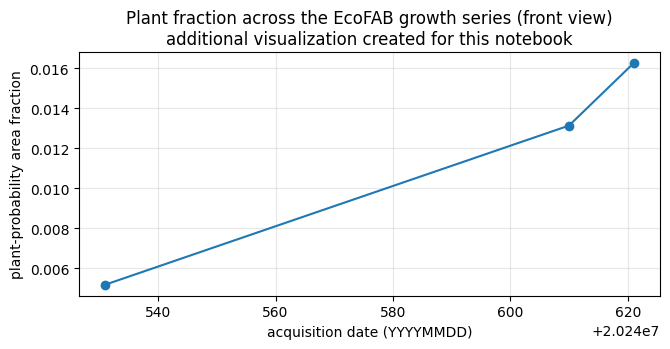

In [ ]:
fig, ax = plt.subplots(figsize=(6.8, 3.6))
ax.plot(trend_df["date"], trend_df["plant_fraction"], marker="o")
ax.set_xlabel("acquisition date (YYYYMMDD)")
ax.set_ylabel("plant-probability area fraction")
ax.set_title("Plant fraction across the EcoFAB growth series (front view)\n"
             "additional visualization created for this notebook")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Interpretation, limitations, validation record / 解釈・限界・検証記録

**Interpretation.** The ensemble reproduces the paper's segmentation behavior on this sample: a coherent plant probability region with the highest uncertainty at leaf edges and in the EcoFAB housing reflections (cf. paper Fig. 4), and an increasing plant area fraction across the growth series.

**Limitations / スコープの限界.**
- One view (front) of one EcoFAB (`YY24EX0010EF009`), three of twelve time points — a minimal partial demonstration, **not** a verification of the paper's dataset-level results (e.g., 98% validation macro-F1).
- The patch/stitch/ensemble glue is AI-generated (documented above); the numerical operations follow paper §3.4 and the author classes, but no author reference output exists for a per-pixel comparison.
- The reference-mask check is a plausibility check, not a scored validation.
- Training, SVD ensemble analysis (paper Fig. 5), and UMAP/NDVI analyses are out of scope.

**Validation record.** This notebook was executed top-to-bottom on a fresh Google Colab CPU runtime on 2026-10-07; all checksums (git blob SHA-1 for the six reference arrays, Zenodo md5 for the five checkpoints and the 3.65 GB archive) were verified in-runtime, and the emitted outputs in this file are from that run.

**Provenance.** Paper: DOI 10.3389/fhpcp.2025.1547340 (CC BY 4.0). Code: github.com/phzwart/ecospec @ `65ca88ab` (BSD-3-Clause); dlsia 0.3.1; qlty 0.2.0. Data/weights: Zenodo record 14607017 (CC BY 4.0).

In [ ]:
print(f"Notebook wall time: {(time.time()-t_notebook)/60:.1f} min")
import torch, dlsia, ecospec, qlty, numpy
print("versions -> torch", torch.__version__, "| dlsia", dlsia.__version__,
      "| ecospec", ecospec.__version__, "| qlty", qlty.__version__,
      "| numpy", numpy.__version__, "| device:", DEVICE)

Notebook wall time: 16.0 min
versions -> torch 2.11.0+cpu | dlsia 0.3.1 | ecospec 0.1.0 | qlty 0.2.0 | numpy 2.1.3 | device: cpu
